In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import os
from PIL import Image

from myDataset import *

# imports loss, accuracy and confusion matrix plots
from MetricMethods import *

# imports train, test methods
from ArchitectureMethods import *



seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.empty_cache()

# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/user/HS401/ob00564/Documents/COM3001/Custom All
/user/HS401/ob00564/Documents/COM3001
cuda


In [2]:
# Dataset Creation
train_dataset = myDataset(directory = "Custom All/DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "Custom All/DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "Custom All/DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

# DataLoader Creation
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers=8)

Train set length: 3241
Test set length: 404
Validation set length: 408


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class ArchitectureFour(nn.Module):
    
    def __init__(self):
        super(ArchitectureFour, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, stride = 1, padding = 1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size = 3, stride = 1, padding = 1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)  

        self.batch_norm1 = nn.BatchNorm2d(32)
        self.batch_norm2 = nn.BatchNorm2d(64)
        self.batch_norm3 = nn.BatchNorm2d(128)
        self.batch_norm4 = nn.BatchNorm2d(256)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(14 * 14 * 256, 256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128, 7)

        self.dropout1 = nn.Dropout(p=0.5)
        self.dropout2 = nn.Dropout(p=0.5)
        self.dropout3 = nn.Dropout(p=0.5)
        self.dropout4 = nn.Dropout(p=0.5)

    def forward(self, x):

        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)
        # Output = 112 x 112 x 32

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout2(x)
         # Output = 56 x 56 x 64

        x = self.conv3(x)
        x = self.batch_norm3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout3(x)
         # Output = 28 x 28 x 128

        x = self.conv4(x)
        x = self.batch_norm4(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout4(x)
         # Output = 14 x 14 x 256

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)

        return x


/user/HS401/ob00564/Documents/COM3001
Predicted Class: 0


/tmp/ipykernel_2809516/2610971222.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Four/Unweighted Architectur

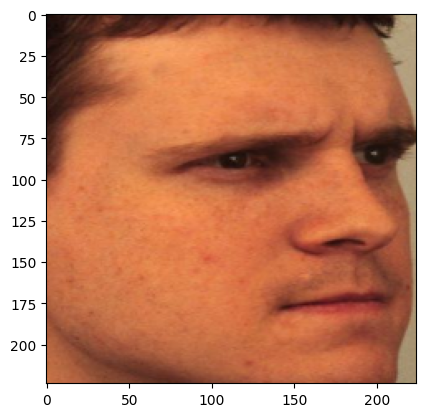

In [4]:

myModel = ArchitectureFour()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Four/Unweighted Architecture Four SGD.pth'))
myModel.to('cuda')
myModel.eval()


# Used to get code on how to test a singular image: https://www.youtube.com/watch?v=H1pfPRQvO_w&list=LL&index=1
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[.229,.224,.225]),
])


img = Image.open('Custom All/DATASET/test/0/0 Index 188.png')
img_tensor = test_transform(img).float()
img_tensor = img_tensor.unsqueeze(0)
test = img_tensor.to('cuda')

with torch.no_grad():
    output = myModel(test)

_, pred = torch.max(output, 1)
print("Predicted Class: " + str(pred.item()))

plt.imshow(img)

